Basic Dataset Information
Dataset shape: (10000, 5)

First 5 rows:
   temperature   pressure   flow_rate  vibration  failure
0   159.934283   6.643011  217.414312   3.019428        0
1   147.234714   7.389001  214.166180   3.945014        0
2   162.953771   6.805238  153.174008   4.412972        0
3   180.460597   8.220836  228.979211   5.149669        0
4   145.316933  10.394357  125.495866   6.024162        0

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  10000 non-null  float64
 1   pressure     10000 non-null  float64
 2   flow_rate    10000 non-null  float64
 3   vibration    10000 non-null  float64
 4   failure      10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB
None

Descriptive statistics:
        temperature      pressure     flow_rate     vibration       fa

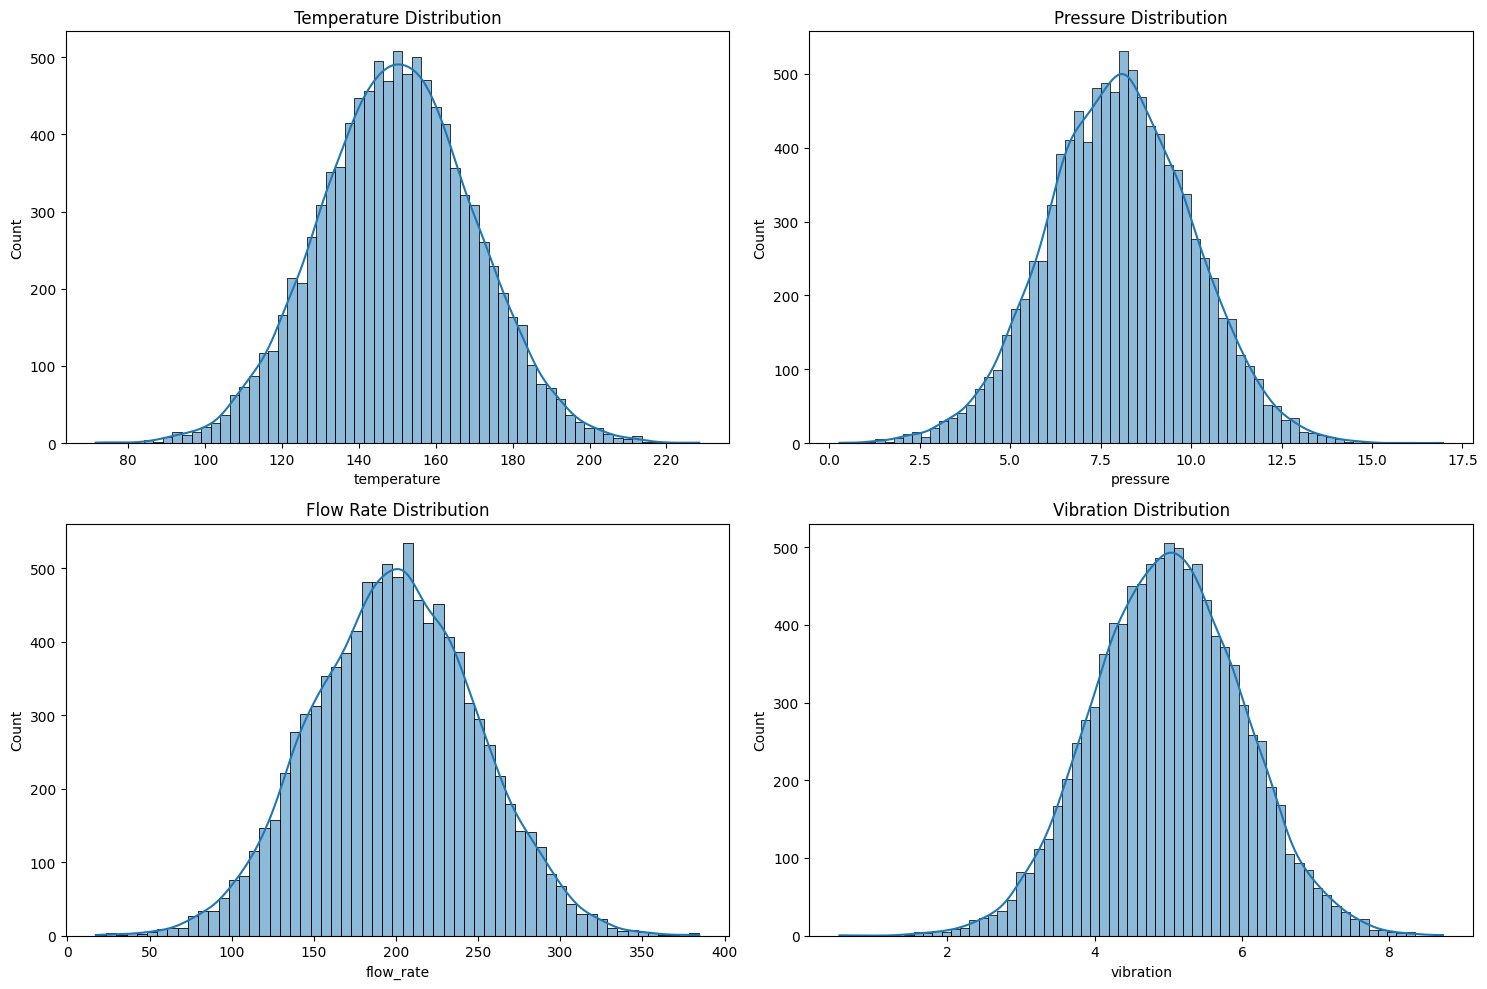

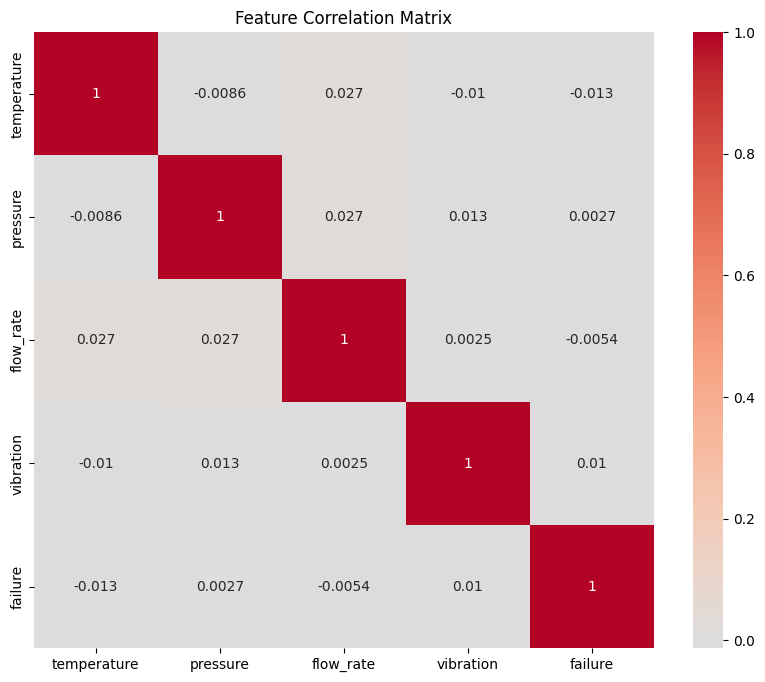

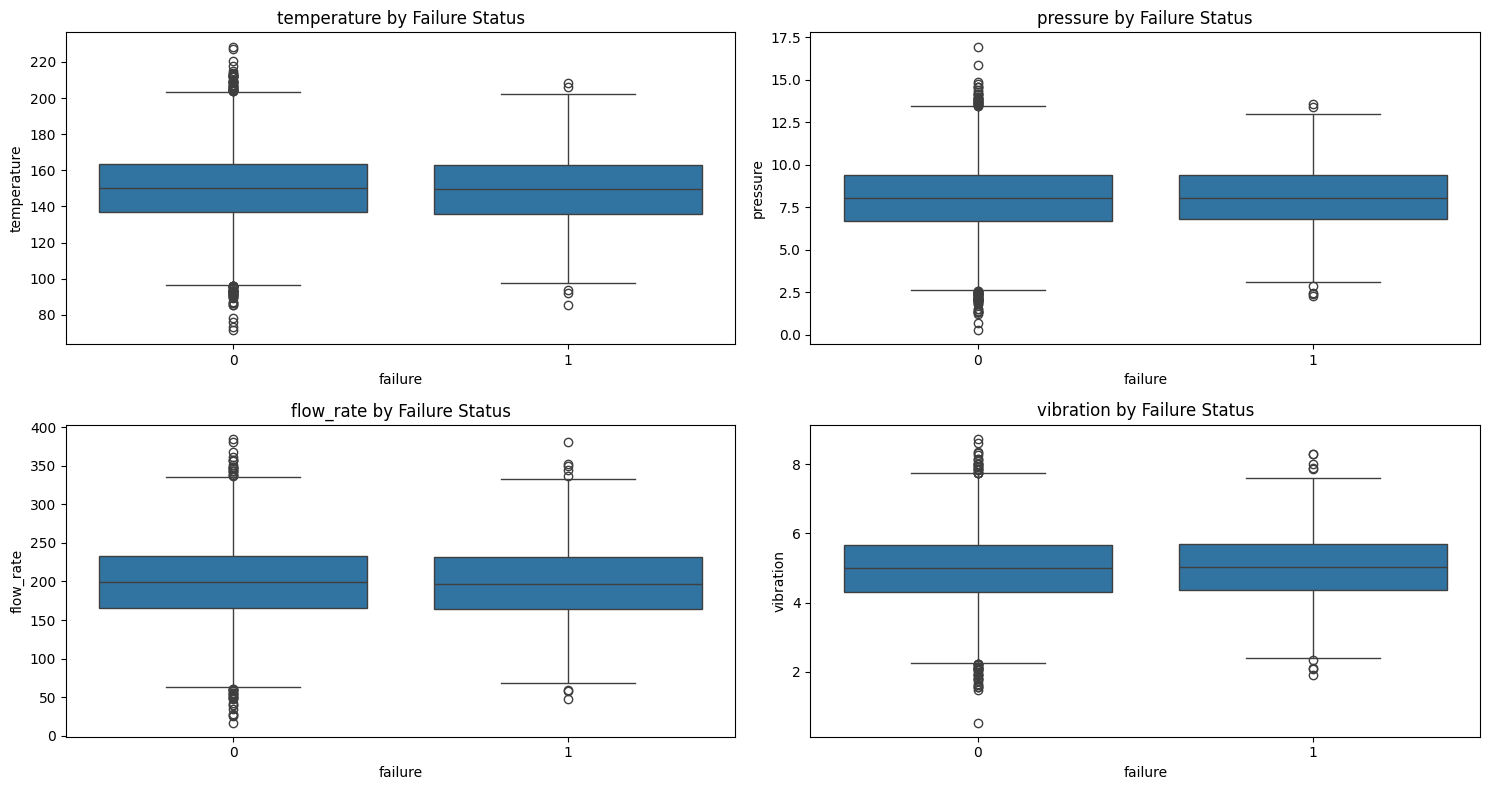


Training Random Forest...

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2710
           1       0.00      0.00      0.00       290

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.82      0.90      0.86      3000


Training Support Vector Machine...

Support Vector Machine Performance:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2710
           1       0.00      0.00      0.00       290

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.82      0.90      0.86      3000


Training Neural Network...

Neural Network Performance:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2710
           1       0.00      0.00      0.00       29

<Figure size 1000x600 with 0 Axes>

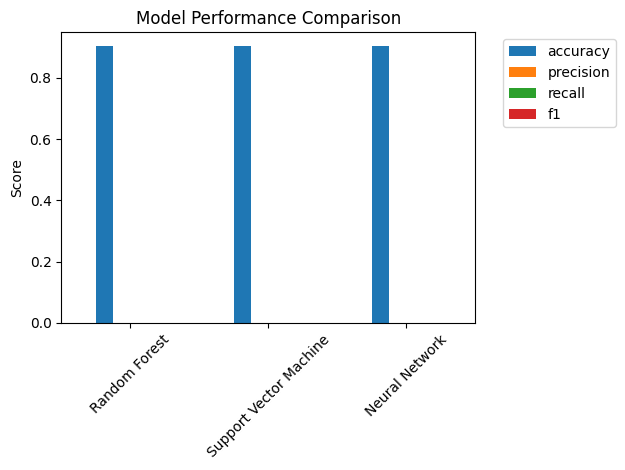


Hyperparameter tuning for Random Forest...
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best F1 score: 0.0029

Final Model Performance:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2710
           1       0.00      0.00      0.00       290

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.82      0.90      0.86      3000



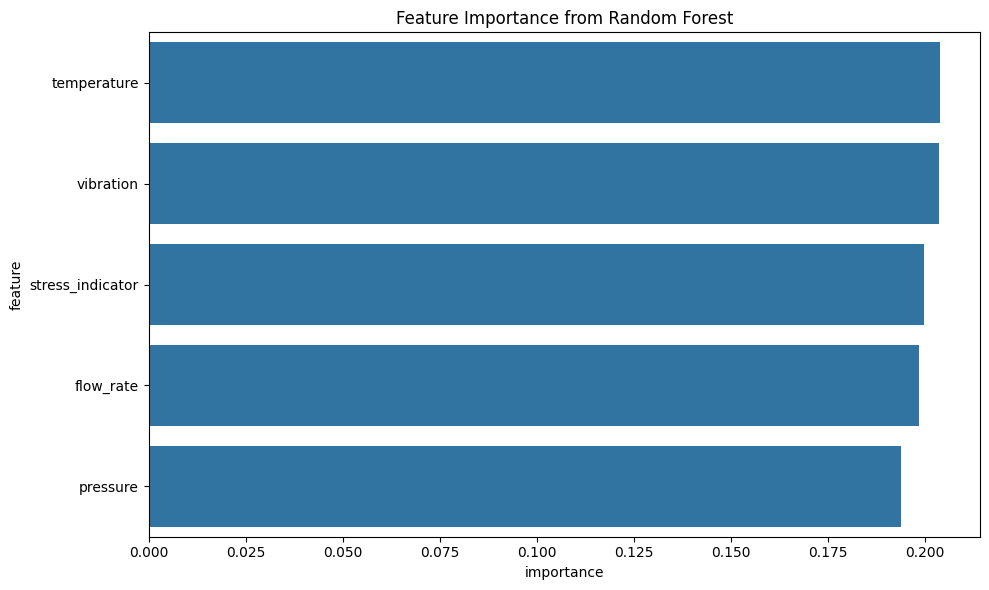

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
url = "https://www.kaggle.com/datasets/inIT-OWL/production-plant-data-for-condition-monitoring"
# Note: You'll need to download the dataset from Kaggle first and adjust the path
# For this example, I'll create a synthetic dataset similar to what's described
# In practice, you would use: df = pd.read_csv('path_to_your_data.csv')

# Create synthetic data for demonstration (replace with actual data loading)
np.random.seed(42)
n_samples = 10000
data = {
    'temperature': np.random.normal(150, 20, n_samples),
    'pressure': np.random.normal(8, 2, n_samples),
    'flow_rate': np.random.normal(200, 50, n_samples),
    'vibration': np.random.normal(5, 1, n_samples),
    'failure': np.random.choice([0, 1], size=n_samples, p=[0.9, 0.1])
}
df = pd.DataFrame(data)

# Exploratory Data Analysis (EDA)
print("="*50)
print("Basic Dataset Information")
print("="*50)
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())
print("\nDescriptive statistics:")
print(df.describe())
print("\nClass distribution (failure vs non-failure):")
print(df['failure'].value_counts(normalize=True))

# Visualization
plt.figure(figsize=(15, 10))

# Distribution of features
plt.subplot(2, 2, 1)
sns.histplot(df['temperature'], kde=True)
plt.title('Temperature Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['pressure'], kde=True)
plt.title('Pressure Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['flow_rate'], kde=True)
plt.title('Flow Rate Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df['vibration'], kde=True)
plt.title('Vibration Distribution')

plt.tight_layout()
plt.show()

# Correlation analysis
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

# Boxplots to compare features by failure status
plt.figure(figsize=(15, 8))
for i, col in enumerate(['temperature', 'pressure', 'flow_rate', 'vibration']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x='failure', y=col, data=df)
    plt.title(f'{col} by Failure Status')
plt.tight_layout()
plt.show()

# Data Preprocessing
# Handle missing values (if any)
df.fillna(df.mean(), inplace=True)

# Feature engineering (example: create a stress indicator)
df['stress_indicator'] = df['temperature'] * df['pressure'] / df['flow_rate']

# Split data into features and target
X = df.drop('failure', axis=1)
y = df['failure']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Development
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'Neural Network': MLPClassifier(random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Store results
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    # Print classification report
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))

# Compare model performance
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df)

# Visualize model performance
plt.figure(figsize=(10, 6))
results_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Hyperparameter tuning for the best model (Random Forest in this case)
print("\nHyperparameter tuning for Random Forest...")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_rf = grid_search.best_estimator_
y_pred_final = best_rf.predict(X_test_scaled)

print("\nFinal Model Performance:")
print(classification_report(y_test, y_pred_final))

# Feature importance
feature_importance = best_rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'feature': features, 'importance': feature_importance})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

# Save the model (uncomment to use)
# import joblib
# joblib.dump(best_rf, 'boiler_failure_predictor.pkl')
# joblib.dump(scaler, 'scaler.pkl')

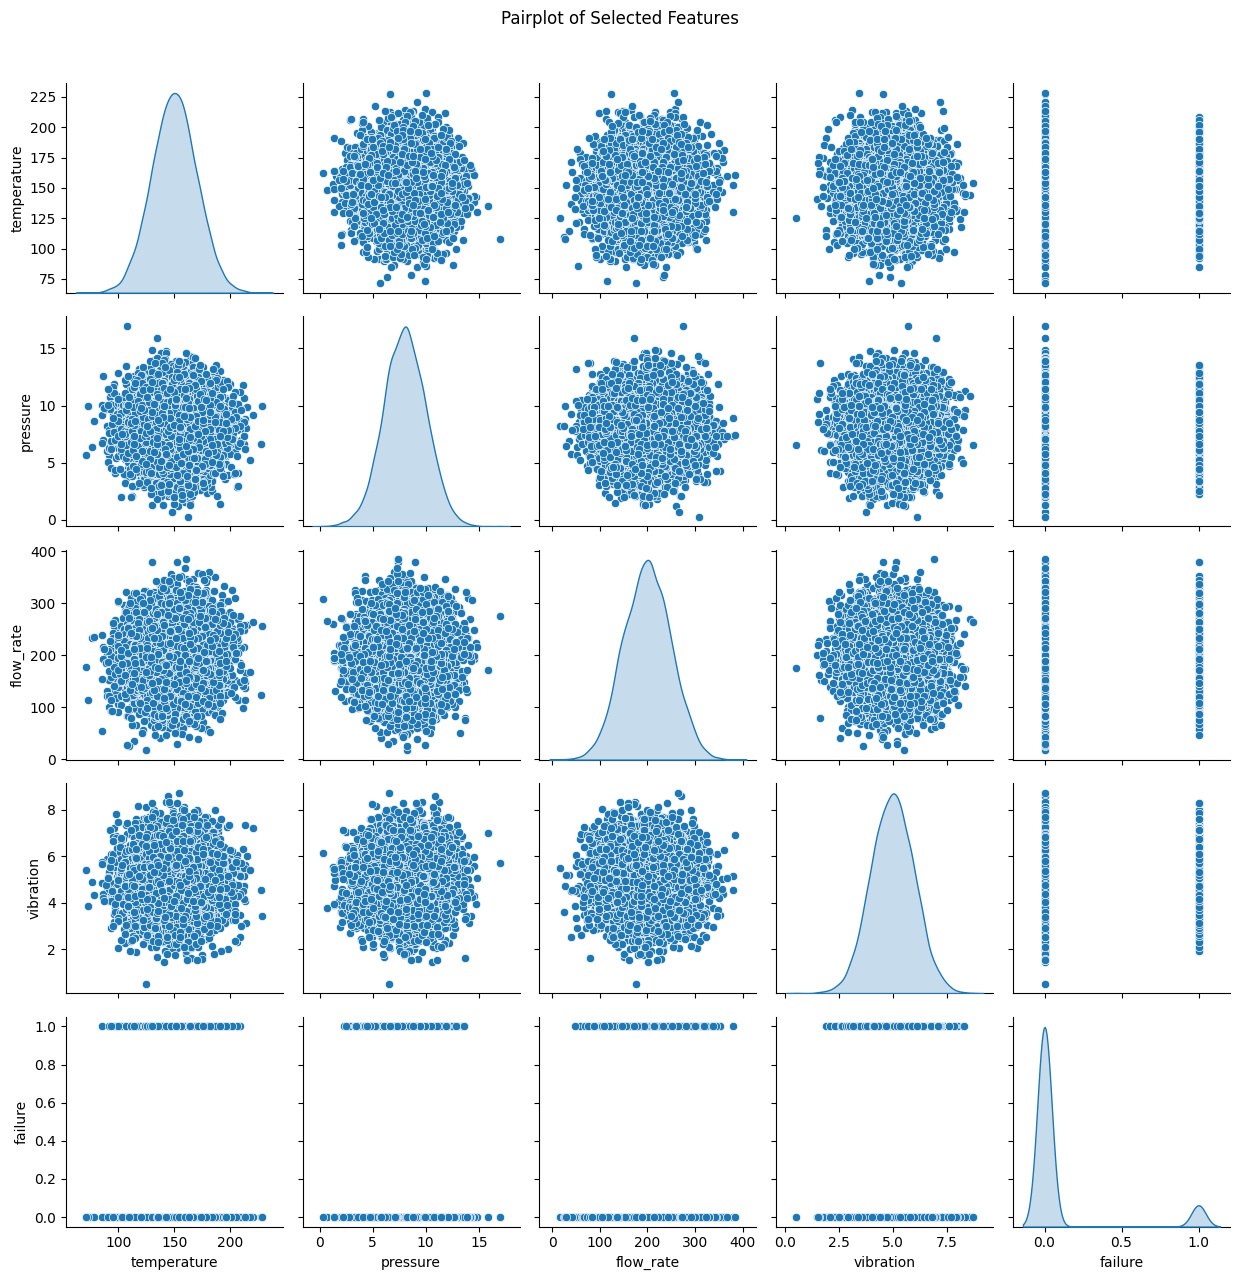

In [2]:
# Pairplot for the first five numerical features (for visualizing relationships)
sns.pairplot(df.iloc[:, :5], diag_kind="kde")
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.tight_layout()
plt.show()

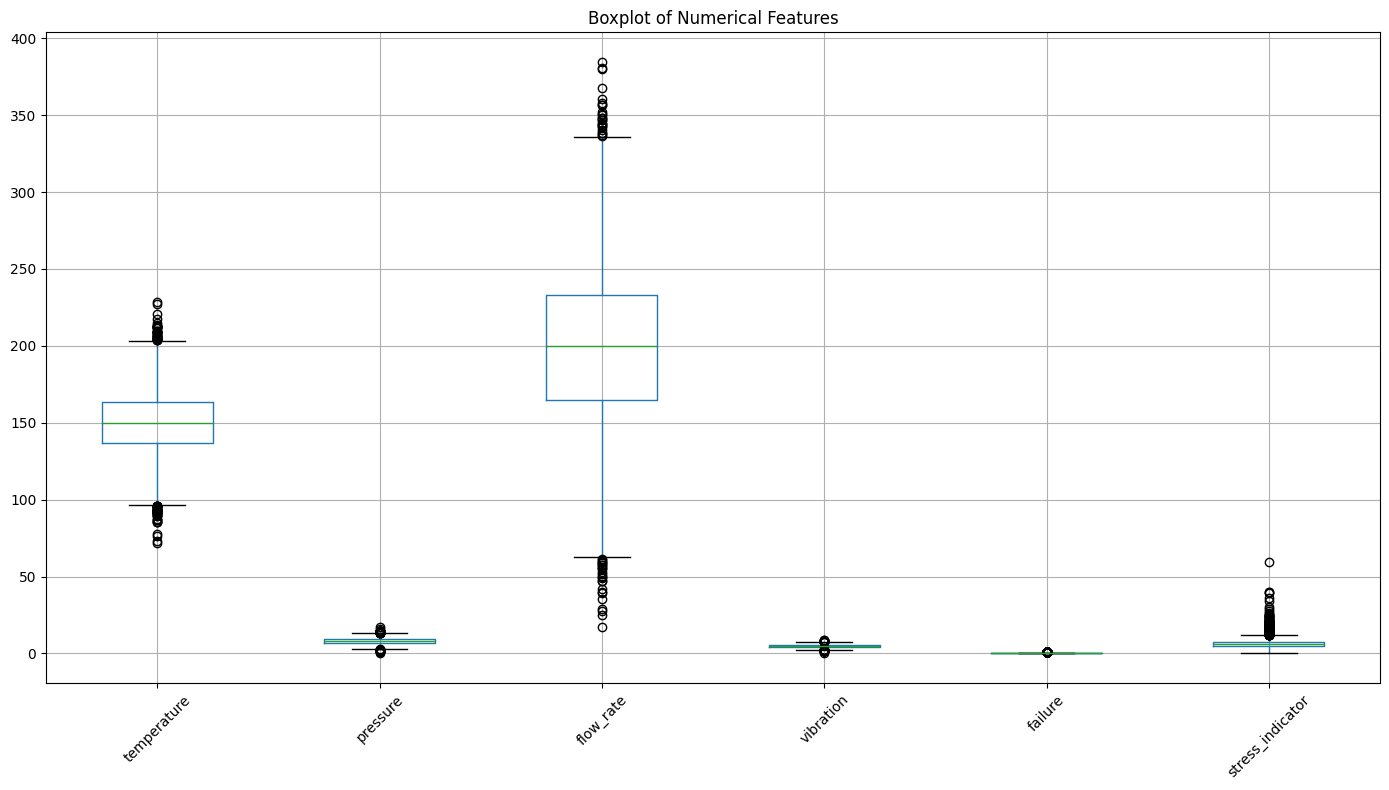

In [3]:
# Boxplots to observe distribution and potential outliers in numerical features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 8))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
# Import model-related libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the name of your target column
target_col = 'failure'  # Ensure 'failure' is a string and replace with your actual target column name

# Define features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Standardize the feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [9]:
# Initialize and train SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Predict and evaluate
svm_predictions = svm_model.predict(X_test)
print("SVM Classification Report:")
print(classification_report(y_test, svm_predictions))


SVM Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1811
           1       0.00      0.00      0.00       189

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000



In [10]:
# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_predictions = rf_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1811
           1       0.00      0.00      0.00       189

    accuracy                           0.90      2000
   macro avg       0.45      0.50      0.47      2000
weighted avg       0.82      0.90      0.86      2000



In [11]:
# Define ANN architecture
ann_model = Sequential()
ann_model.add(Dense(32, input_shape=(X_train.shape[1],), activation='relu'))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
ann_model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)

# Evaluate on test set
ann_predictions = (ann_model.predict(X_test) > 0.5).astype("int32")

print("ANN Classification Report:")
print(classification_report(y_test, ann_predictions))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1811
           1       0.00      0.00      0.00       189

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000



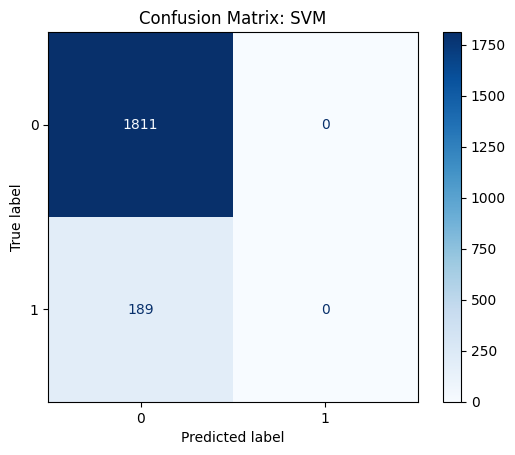

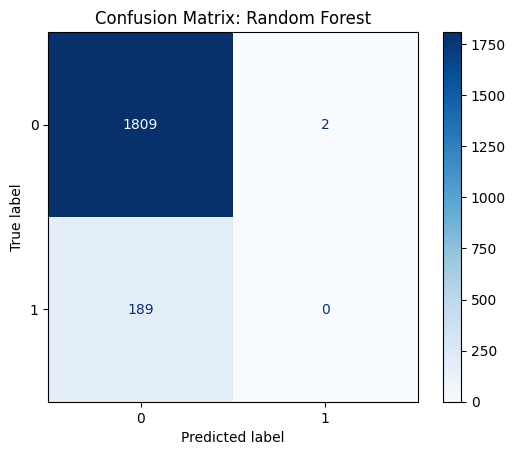

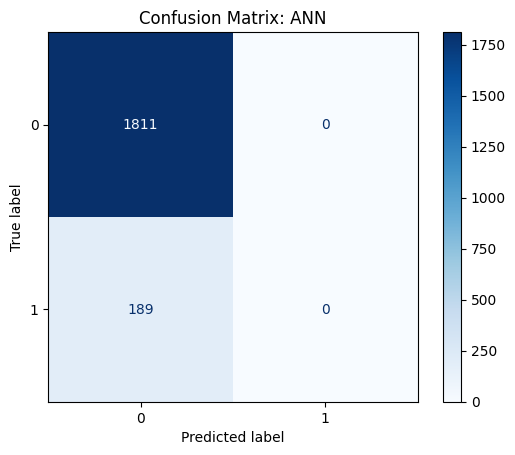

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.grid(False)
    plt.show()

# Plot for each model
plot_confusion_matrix(y_test, svm_predictions, "Confusion Matrix: SVM")
plot_confusion_matrix(y_test, rf_predictions, "Confusion Matrix: Random Forest")
plot_confusion_matrix(y_test, ann_predictions, "Confusion Matrix: ANN")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


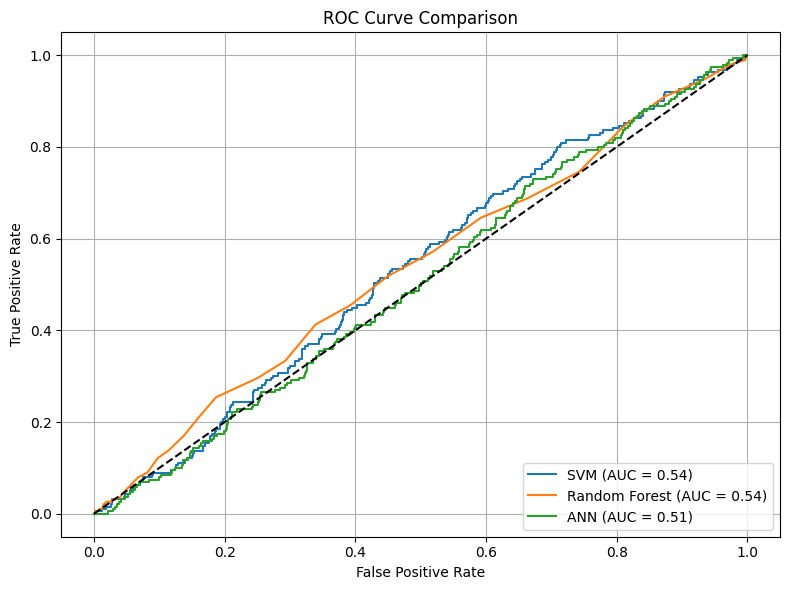

In [13]:
from sklearn.metrics import roc_curve, auc

# Get probability scores
svm_proba = svm_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]
ann_proba = ann_model.predict(X_test).ravel()

# Compute ROC curves
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_ann, tpr_ann, _ = roc_curve(y_test, ann_proba)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = {:.2f})".format(auc(fpr_svm, tpr_svm)))
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = {:.2f})".format(auc(fpr_rf, tpr_rf)))
plt.plot(fpr_ann, tpr_ann, label="ANN (AUC = {:.2f})".format(auc(fpr_ann, tpr_ann)))

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
